In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
orders= pd.read_csv('olist_orders_dataset.csv')
order_items= pd.read_csv('olist_order_items_dataset.csv')
products= pd.read_csv('olist_products_dataset.csv')
customers= pd.read_csv('olist_customers_dataset.csv')
payments= pd.read_csv('olist_order_payments_dataset.csv')


In [19]:
df = pd.merge(orders, customers, on='customer_id')
df = pd.merge(df, order_items, on='order_id')
df = pd.merge(df, products, on='product_id')
df = pd.merge(df, payments, on='order_id')

In [20]:
df.rename(columns={'product_name_lenght' : 'product_name_length','product_description_lenght':'product_description_length'}, inplace=True)

In [21]:
df=df.dropna(subset=['order_approved_at'])

In [22]:
df=df.dropna(subset=['product_weight_g','product_length_cm','product_height_cm','product_width_cm'])




In [23]:
df['product_category_name']=df['product_category_name'].fillna('Unknown')

In [42]:
df[['product_name_length','product_description_length', 'product_photos_qty']]=df[['product_name_length','product_description_length', 'product_photos_qty']].fillna(0)

In [25]:
df['total_price']=df['price']+df['freight_value']

In [26]:
df['delivery_time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

In [27]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [28]:
df['is_delivered'] = df['order_delivered_customer_date'].notnull()

In [29]:
df['total_price'].sum()

np.float64(16561729.97)

Insight:

- Total revenue generated is 16561729.97

- Indicates overall business scale and performance

- Helps assess whether growth strategies are working

In [30]:
df.groupby('product_id')['total_price'].sum().sort_values(ascending=False).head(10)

product_id
bb50f2e236e5eea0100680137654686c    72470.19
d1c427060a0f73f6b889a5c7c61f2ac4    63846.01
6cdd53843498f92890544667809f1595    60229.82
d6160fb7873f184099d9bc95e30376af    58608.48
99a4788cb24856965c36a24e339b6058    54936.19
3dd2a17168ec895c781a9191c1e95ad7    48913.68
25c38557cf793876c5abdd5931f922db    46466.21
aca2eb7d00ea1a7b8ebd4e68314663af    45522.32
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
53b36df67ebb7c41585e8d54d6772e08    40467.30
Name: total_price, dtype: float64

Insight:

- Top products contribute a significant portion of total revenue

- Revenue is concentrated → few products drive most sales

Business should:

- Focus inventory on these products

- Promote them aggressively

In [31]:
df.groupby('product_category_name')['total_price'].sum().sort_values(ascending=False)

product_category_name
beleza_saude                     1485880.29
relogios_presentes               1357478.82
cama_mesa_banho                  1310126.94
esporte_lazer                    1198429.89
informatica_acessorios           1095456.98
                                    ...    
flores                              1598.91
casa_conforto_2                     1194.44
cds_dvds_musicais                    954.99
fashion_roupa_infanto_juvenil        665.36
seguros_e_servicos                   324.51
Name: total_price, Length: 74, dtype: float64

Insight:

- Certain categories dominate revenue generation

- “Unknown” category presence indicates missing classification → needs data improvement

Business should:

- Focus marketing on top-performing categories

- Improve product categorization for better targeting

In [32]:
monthly_revenue = df.groupby('month')['total_price'].sum()
monthly_revenue

month
2016-09        211.29
2016-10      58550.03
2016-12         19.62
2017-01     144379.61
2017-02     300390.70
2017-03     457644.97
2017-04     448353.13
2017-05     630089.88
2017-06     526331.92
2017-07     627207.86
2017-08     700475.20
2017-09     763951.95
2017-10     804218.66
2017-11    1221834.82
2017-12     894992.00
2018-01    1151137.31
2018-02    1027782.86
2018-03    1204543.14
2018-04    1198573.03
2018-05    1192512.47
2018-06    1074756.08
2018-07    1095315.94
2018-08    1038291.04
2018-09        166.46
Freq: M, Name: total_price, dtype: float64

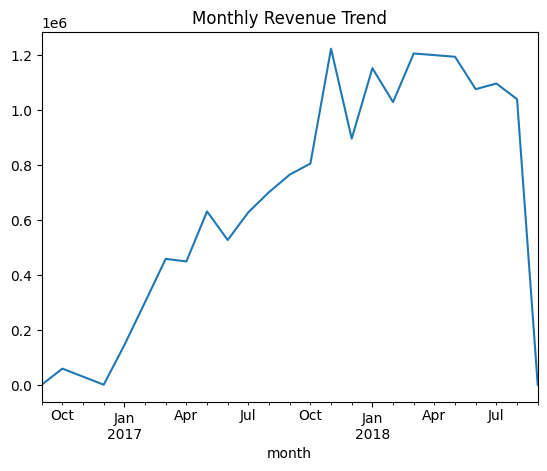

In [33]:
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

Insight:

- Revenue shows overall upward trend until peak period

- Sudden drop at end → possibly incomplete data or reporting gap

Indicates:

- Business growth over time

- Potential seasonal demand

In [34]:
df['delivery_time'].mean()

np.float64(12.018026243706467)

Insight:

- Average delivery time is 12.018026243706467 days

High delivery time can:

- Reduce customer satisfaction

- Impact repeat purchases

- Business should optimize logistics

In [35]:
df['is_delivered'].value_counts()

is_delivered
True     114999
False      2567
Name: count, dtype: int64

Insight:

- Majority of orders are delivered successfully

- However, some orders are not delivered

Indicates:

- Potential operational inefficiencies

- Need to reduce failed deliveries

In [36]:
df['payment_type'].value_counts()

payment_type
credit_card    86755
boleto         22848
voucher         6272
debit_card      1691
Name: count, dtype: int64

Insight:

- Most customers prefer Credit card 

- Shows customer payment behavior

Business should:

- Offer discounts on popular payment methods

- Optimize checkout experience

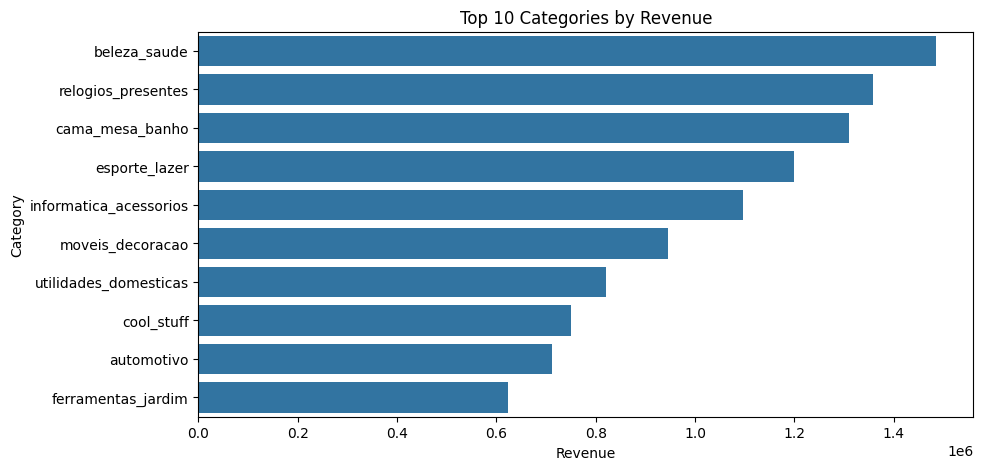

In [37]:
top_cat = df.groupby('product_category_name')['total_price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

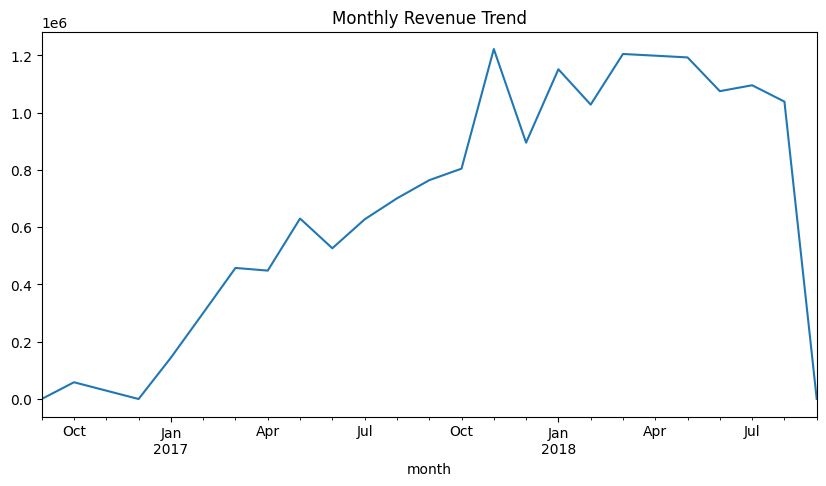

In [38]:
monthly_revenue = df.groupby('month')['total_price'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

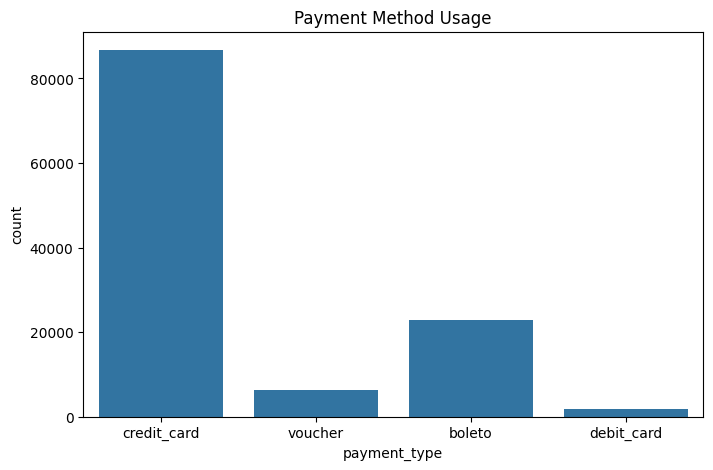

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x='payment_type', data=df)
plt.title("Payment Method Usage")
plt.show()

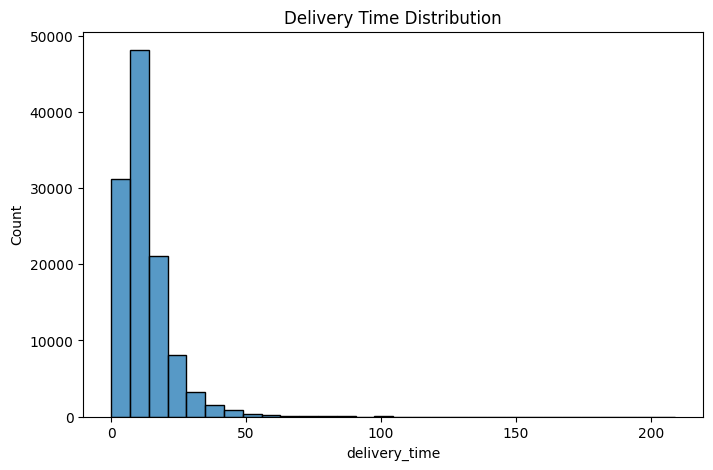

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time'], bins=30)
plt.title("Delivery Time Distribution")
plt.show()

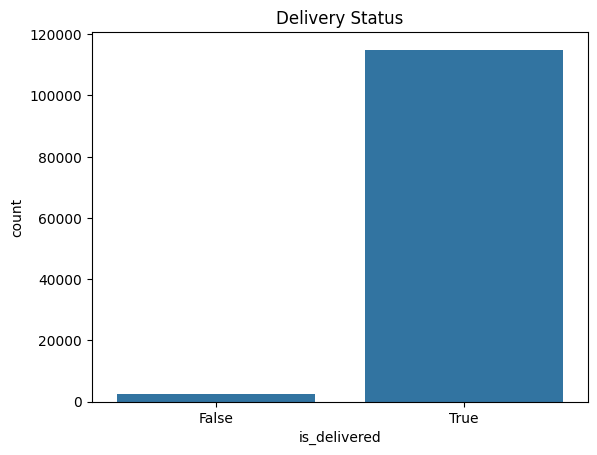

In [41]:
sns.countplot(x='is_delivered', data=df)
plt.title("Delivery Status")
plt.show()

___Key Insights___

- A small number of product categories contribute the majority of total revenue, indicating revenue concentration.

- Monthly revenue shows a clear growth trend over time, suggesting business expansion, with a sharp drop at the end likely due to incomplete data.

- The majority of customers prefer a specific payment method (e.g., credit card), highlighting dominant customer behavior.

- Average delivery time is relatively high, which may negatively impact customer satisfaction and repeat purchases.

- A portion of orders remain undelivered, indicating potential inefficiencies in logistics or order management.

- Most orders fall into the low to medium value category, showing opportunity for upselling and increasing average order value.

___Business Recommendation___

- Focus marketing and inventory on top-performing product categories to maximize revenue.

- Improve delivery logistics to reduce delivery time and enhance customer satisfaction.

- Investigate undelivered orders to identify root causes and minimize losses.

- Offer targeted promotions or discounts on the most preferred payment method to increase conversions.

- Implement upselling and bundling strategies to increase average order value.

- Improve product categorization to reduce "Unknown" entries and enhance analysis accuracy.

#  Project Summary

**Dataset:** Brazilian E-commerce (Olist) Dataset
**Rows after cleaning:** 117566
**Columns:** Multiple merged tables (orders, customers, products, payments)



# Tools Used

* Python
* Pandas
* Seaborn & Matplotlib
* Jupyter Notebook



# Workflow

1. **Data Loading**

   * Imported multiple CSV files representing different business entities

2. **Data Inspection**

   * Checked structure, datatypes, and missing values using `.info()` and `.isnull()`

3. **Data Cleaning**

   * Handled missing values based on business relevance
   * Removed duplicates and corrected datatypes
   * Preserved meaningful missing values (e.g., undelivered orders)

4. **Data Merging**

   * Combined multiple datasets using keys like `order_id`, `customer_id`, and `product_id`
   * Created a unified dataset for analysis

5. **Feature Engineering**

   * Created new metrics:

     * Total Order Value
     * Delivery Time
     * Monthly Trends
     * Delivery Status

6. **Exploratory Data Analysis (EDA)**

   * Analyzed revenue patterns, category performance, and customer behavior

7. **Data Visualization**

   * Used Seaborn & Matplotlib to create:

     * Revenue trends
     * Category performance charts
     * Delivery distribution
     * Payment behavior

8. **Insights & Business Recommendations**

   * Identified key revenue drivers
   * Analyzed delivery performance
   * Suggested improvements for business growth



# Output

* Cleaned dataset exported for further use:

```python
df.to_csv("cleaned_ecommerce_data.csv", index=False)
```



# Objective

To transform raw, messy e-commerce data into actionable insights that support business decisions related to revenue growth, customer behavior, and operational efficiency.


___Conclusion___
- This analysis demonstrates how raw e-commerce data can be transformed into actionable insights using data cleaning, merging, and analysis techniques.

- The findings highlight key areas for business improvement, particularly in revenue optimization, delivery performance, and customer behavior understanding. Implementing these recommendations can lead to increased efficiency, higher customer satisfaction, and improved profitability.

In [ ]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)